# SEAS5 monitoring 2025

<!-- markdownlint-disable MD013 -->

Monitoring SEAS5 forecast for 2025 updated framework.

Trigger if AOI has at least 10% of area with seasonal rainfall in lowest quintile.

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import calendar

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter
from scipy.stats import percentileofscore
from dask.diagnostics import ProgressBar

from src.datasources import seas5, codab
from src.constants import *
from src.utils.raster import upsample_dataarray

In [3]:
THRESH = 0.2

## Load data

### CODAB

In [4]:
adm1 = codab.load_codab_from_blob(admin_level=1, aoi_only=True)

### SEAS5 current

Set `window` based on monitoring window (1 is March, 2 is July).

In [5]:
window = 1
year = 2026

In [6]:
mo_lt_combos = ORIGINAL_MO_LT_COMBOS[:window]

In [7]:
mo_lt_combos

[{'mo': 3, 'lts': [3, 4, 5]}]

In [8]:
da_seas5 = seas5.open_seas5_rasters(mo_lt_combos=mo_lt_combos, years=[year])

  0%|          | 0/1 [00:00<?, ?it/s]

In [9]:
# squeeze to remove issued_month
da_seas5_tri = da_seas5.mean(dim="lt").squeeze(drop=True)
da_seas5_up = upsample_dataarray(da_seas5_tri)
da_seas5_clip = da_seas5_up.rio.clip(adm1.geometry)

In [10]:
with ProgressBar():
    da_seas5_current_computed = da_seas5_clip.compute()

[########################################] | 100% Completed | 3.35 sms


In [11]:
da_seas5_current_computed

<xarray.DataArray (y: 38, x: 58)> Size: 9kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * x            (x) float64 464B -4.6 -4.5 -4.4 -4.3 -4.2 ... 0.8 0.9 1.0 1.1
  * y            (y) float64 304B 11.3 11.4 11.5 11.6 ... 14.7 14.8 14.9 15.0
    spatial_ref  int64 8B 0

### SEAS5 historical

In [12]:
# only open the rasters for this window
da_seas5_historical = seas5.open_seas5_rasters(mo_lt_combos=mo_lt_combos)

  0%|          | 0/44 [00:00<?, ?it/s]

In [13]:
# squeeze to remove issued_month
da_seas5_tri_h = da_seas5_historical.mean(dim="lt").squeeze(drop=True)
da_seas5_up_h = upsample_dataarray(da_seas5_tri_h)
da_seas5_clip_h = da_seas5_up_h.rio.clip(adm1.geometry)

In [14]:
with ProgressBar():
    da_seas5_historical_computed = da_seas5_clip_h.compute()

[########################################] | 100% Completed | 45.48 s


In [16]:
da_seas5_historical_computed

<xarray.DataArray (year: 44, y: 38, x: 58)> Size: 388kB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
  * year         (year) int64 352B 1981 1982 1983 1984 ... 2021 2022 2023 2024
  * x            (x) float64 464B -4.6 -4.5 -4.4 -4.3 -4.2 ... 0.8 0.9 1.0 1.1
  * y            (y) float64 304B 11.3 11.4 11.5 11.6 ... 14.7 14.8 14.9 15.0
    spatial_ref  int64 8B 0

## Evaluate trigger

### Calculate pixel-wise percentile

Note that this excludes the current year from the percentile calculation (provided that the current year is not within the reference period 1981-2024), so the distribution doesn't change between monitoring years.

In [17]:
# count the years where value is less than or equal to current value
# then divide by total number of years - this is the percentile rank

# taken together, these two steps are equivalent to taking the mean of the
# boolean of the historical years under/over current value, per pixel

# note that we need to mask again by the NaN areas, since the boolean
# will return False for NaN pixels, instead of NaN

da_current_percentile = (
    (da_seas5_historical_computed <= da_seas5_current_computed)
    .mean(dim="year")
    .where(~da_seas5_current_computed.isnull())
)

In [18]:
da_current_percentile.max()

<xarray.DataArray ()> Size: 8B
array(0.45454545)
Coordinates:
    spatial_ref  int64 8B 0

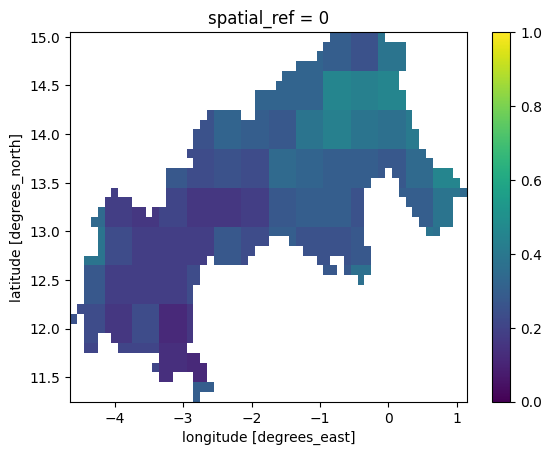

In [19]:
# just check that it looks sensible
da_current_percentile.plot(vmin=0, vmax=1)

### Calculate spatial quantile

Take the 10th spatial quantile. It it's below the theshold (20%), trigger.

In [20]:
da_current_percentile.quantile(ORIGINAL_Q, dim=["x", "y"])

<xarray.DataArray ()> Size: 8B
array(0.15909091)
Coordinates:
    quantile  float64 8B 0.1

Conversely we can look at the fraction of the area under the threshold. If it's above 10%, trigger.

In [21]:
da_triggering = (da_current_percentile < THRESH).where(
    ~da_current_percentile.isnull()
)

In [22]:
frac_area_triggering = float(da_triggering.mean())
frac_area_triggering

0.24829931972789115

## Plotting

In [23]:
mo = mo_lt_combos[0].get("mo")

In [24]:
mo_fr = FRENCH_MONTHS.get(calendar.month_abbr[mo])

In [25]:
v_mo_fr = ", ".join(
    [
        FRENCH_MONTHS.get(calendar.month_abbr[x + mo])
        for x in mo_lt_combos[0].get("lts")
    ]
)

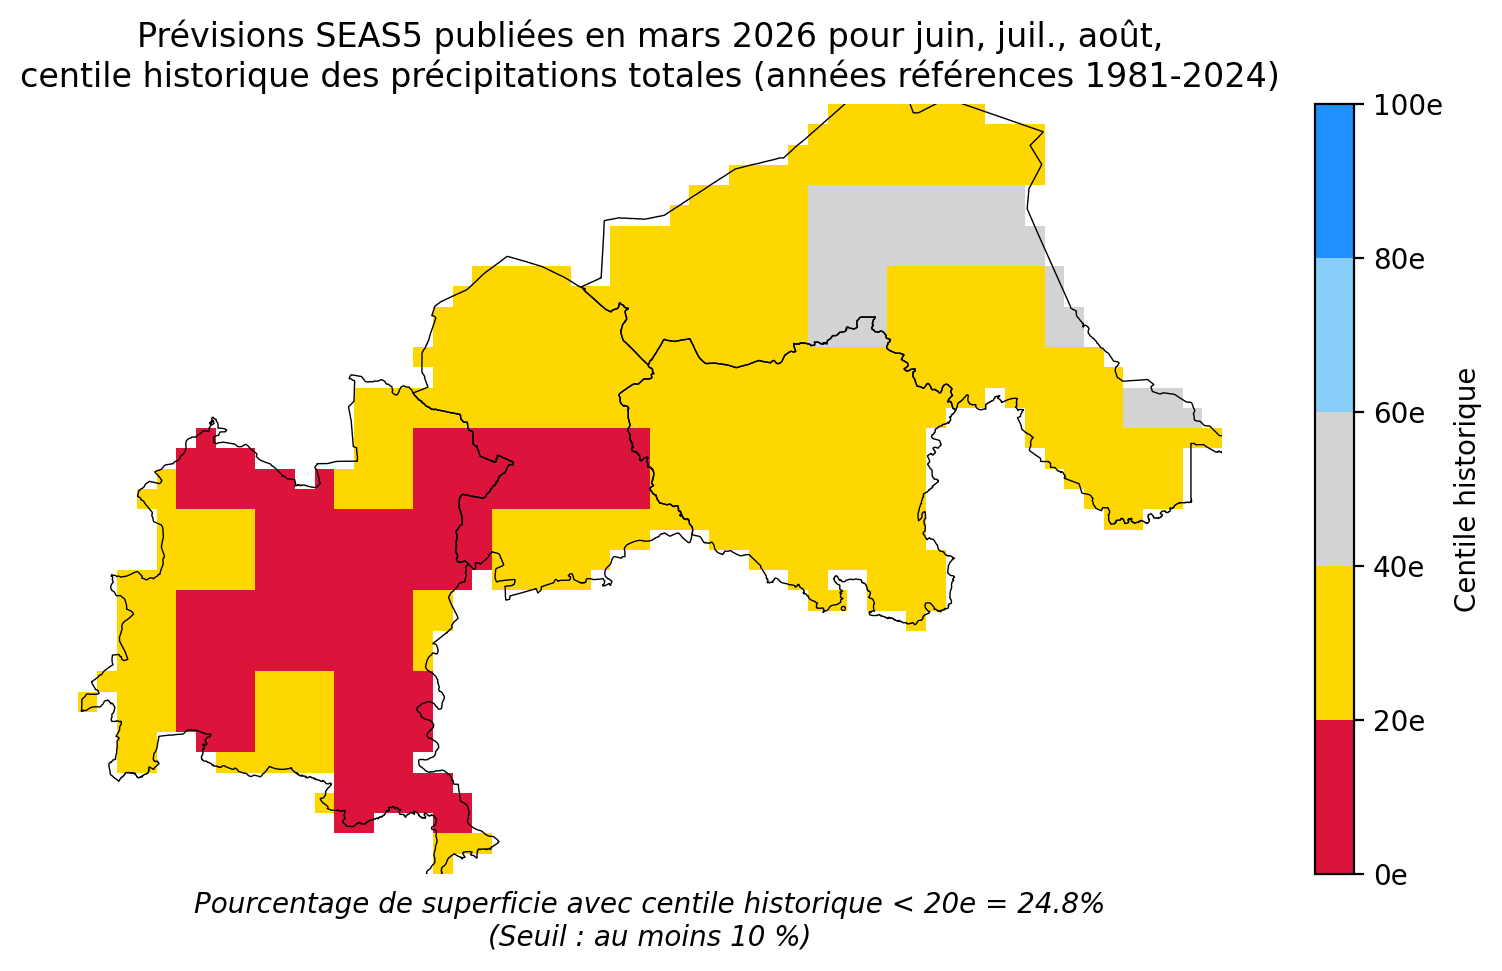

In [27]:
boundaries = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
colors = [
    "crimson",
    "gold",
    "lightgrey",
    "lightskyblue",
    "dodgerblue",
]  # specify your desired colors

# Create a custom colormap
cmap = mcolors.ListedColormap(colors)

# Normalize the values to the specified boundaries
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

# Plot the data
fig, ax = plt.subplots(dpi=200, figsize=(12, 5))
da_current_percentile.plot(cmap=cmap, norm=norm, ax=ax, add_colorbar=False)
ax.axis("off")

adm1.boundary.plot(ax=ax, color="k", linewidth=0.5)

ax.set_title(
    f"Prévisions SEAS5 publiées en {mo_fr} {year} pour {v_mo_fr},\n"
    "centile historique des précipitations totales (années références 1981-2024)"
)

# bottom_text = (
#     f"Fraction de avec centile < {THRESH*100:.0f} = {frac_area_triggering:.1f}"
# )

bottom_text = (
    f"Pourcentage de superficie avec centile historique < {THRESH*100:.0f}e = {frac_area_triggering*100:.1f}%\n"
    "(Seuil : au moins 10 %)"
)

# Add the bottom text with smaller font, italicized
ax.text(
    0.5,
    -0.1,
    bottom_text,
    ha="center",
    va="bottom",
    transform=ax.transAxes,
    fontsize=10,
    style="italic",
    color="black",
)


cbar = plt.colorbar(
    ax.collections[0], ax=ax, norm=norm, cmap=cmap, boundaries=boundaries
)
cbar.set_label("Centile historique")
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x*100:.0f}e"))

## Testing

We can verify that this method of percentile rank calculation correponds to that for the threshold calculation by running the monitoring for the year 2024 and comparing the results

In [65]:
# calculate rank using method in thresholds
da_seas5_historical_ranks = da_seas5_historical_computed.rank(
    dim="year", pct=True
)

In [66]:
da_check = da_seas5_historical_ranks.sel(year=year) == da_current_percentile

KeyError: "not all values found in index 'year'. Try setting the `method` keyword argument (example: method='nearest')."

In [ ]:
# check by plotting- values match everywhere
da_check.plot()